# LUHMES analysis with PerturbVI

Here, we fit the LUHMES CROP Seq data by [Lalli et al.](https://doi.org/10.1101/gr.262295.120) with PerturbVI and analyze the factor effects, gene loadings, differentially expressed genes (DEGs), and neuronal GO enrichment. The dataset contains 14 perturbations and 1 `Nontargeting` control, with 8,708 cells and 6,000 modeled genes. The saved fit uses 20 factors, 1,000 loading components per factor, and PCA initialization.

In [ ]:
# ! uv pip install perturbvi matplotlib

In [ ]:
import pickle
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from perturbvi import PerturbData, estimate_lfsr, fit_screen, save_results
from perturbvi import plotting as pp

plt.rcParams["font.sans-serif"] = ["Arial"]

jax.config.update("jax_enable_x64", True)

### 1. Load data

| File | Contents |
|---|---|
| `data/luhmes_exp.csv` | 8,708 cells x 6,000 genes; processed expression with Ensembl IDs |
| `data/luhmes_G.csv` | Binary assignments for 14 perturbations and 1 `Nontargeting` control across 8,708 cells |
| `data/top6k_genes.csv` | IDs and names for the 6,000 modeled genes |

Expression data is already covariate-corrected and scaled.
Inputs follow the GSFA LUHMES [preprocessing](https://xinhe-lab.github.io/GSFA_paper/preprocess_and_gsfa_LUHMES.html).

In [2]:
data_dir = Path("input")
result_dir = Path("results")

X = pd.read_csv(data_dir / "luhmes_exp.csv", index_col=0)
G = pd.read_csv(data_dir / "luhmes_G.csv", index_col=0).drop(columns=["Nontargeting"])
top6k_genes = pd.read_csv(data_dir / "top6k_genes.csv")

print(
    f"expression: {X.shape}; "
    f"perturbations: {G.shape}; "
    f"genes: {top6k_genes.shape}"
)

expression: (8708, 6000); perturbations: (8708, 14); genes: (6000, 2)


### 2. Fit

`z_dim` sets the factor count.
<br/>
`l_dim` sets loading components per factor.

In [ ]:
screen = PerturbData(X=X, G=G)

fit = fit_screen(screen, z_dim=20, l_dim=1000, init="pca")
save_results(fit, result_dir)

# compute LFSR
lfsr = estimate_lfsr(result_dir, draws=2000)
lfsr.to_csv(result_dir / "LFSR_BW.csv")

### 3. Load Model

`model.pkl` contains the fitted posterior and gene/perturbation names.

| File | Rows x columns | Contents |
|---|---|---|
| `W.csv` | Factors x genes | Inclusion-weighted posterior mean loadings |
| `PIP_W.csv` | Factors x genes | Loading inclusion probabilities |
| `PVE.csv` | Factors x 1 | Per-factor expression variance summary |
| `B.csv` | Perturbations x factors | Inclusion-weighted mean effects on factors |
| `PIP_B.csv` | Perturbations x factors | Coefficient inclusion probabilities |
| `BW.csv` | Perturbations x genes | Overall effects, `B @ W` |
| `LFSR_BW.csv` | Perturbations x genes | Overall-effect sign uncertainty |

In [3]:
with (result_dir / "model.pkl").open("rb") as fh:
    model = pickle.load(fh)

figure_dir = Path("figures")

def save(fig, name):
    fig.savefig(figure_dir / f"{name}.png", dpi=300)
    display(Image(filename=str(figure_dir / f"{name}.png")))
    plt.close(fig)

### 4. Perturbation effects on factors

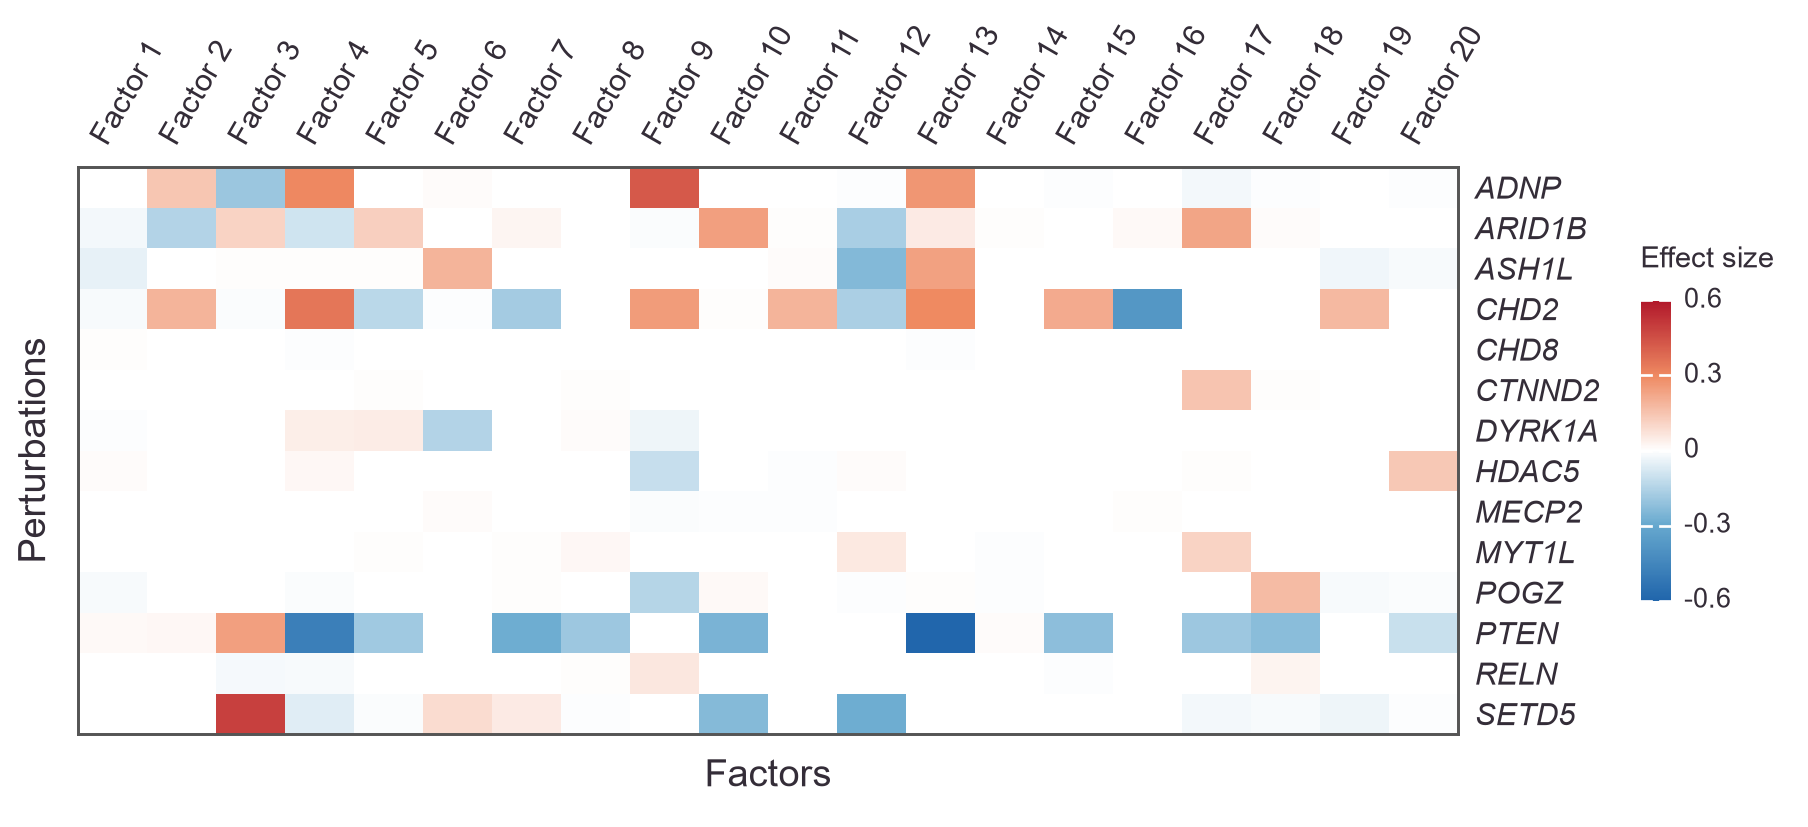

In [4]:
B = pd.read_csv(result_dir / "B.csv", index_col=0)
fig = pp.plot_factor_effects(B)

save(fig, "1_factor_effects")

To show significance based on PIP > 0.95:

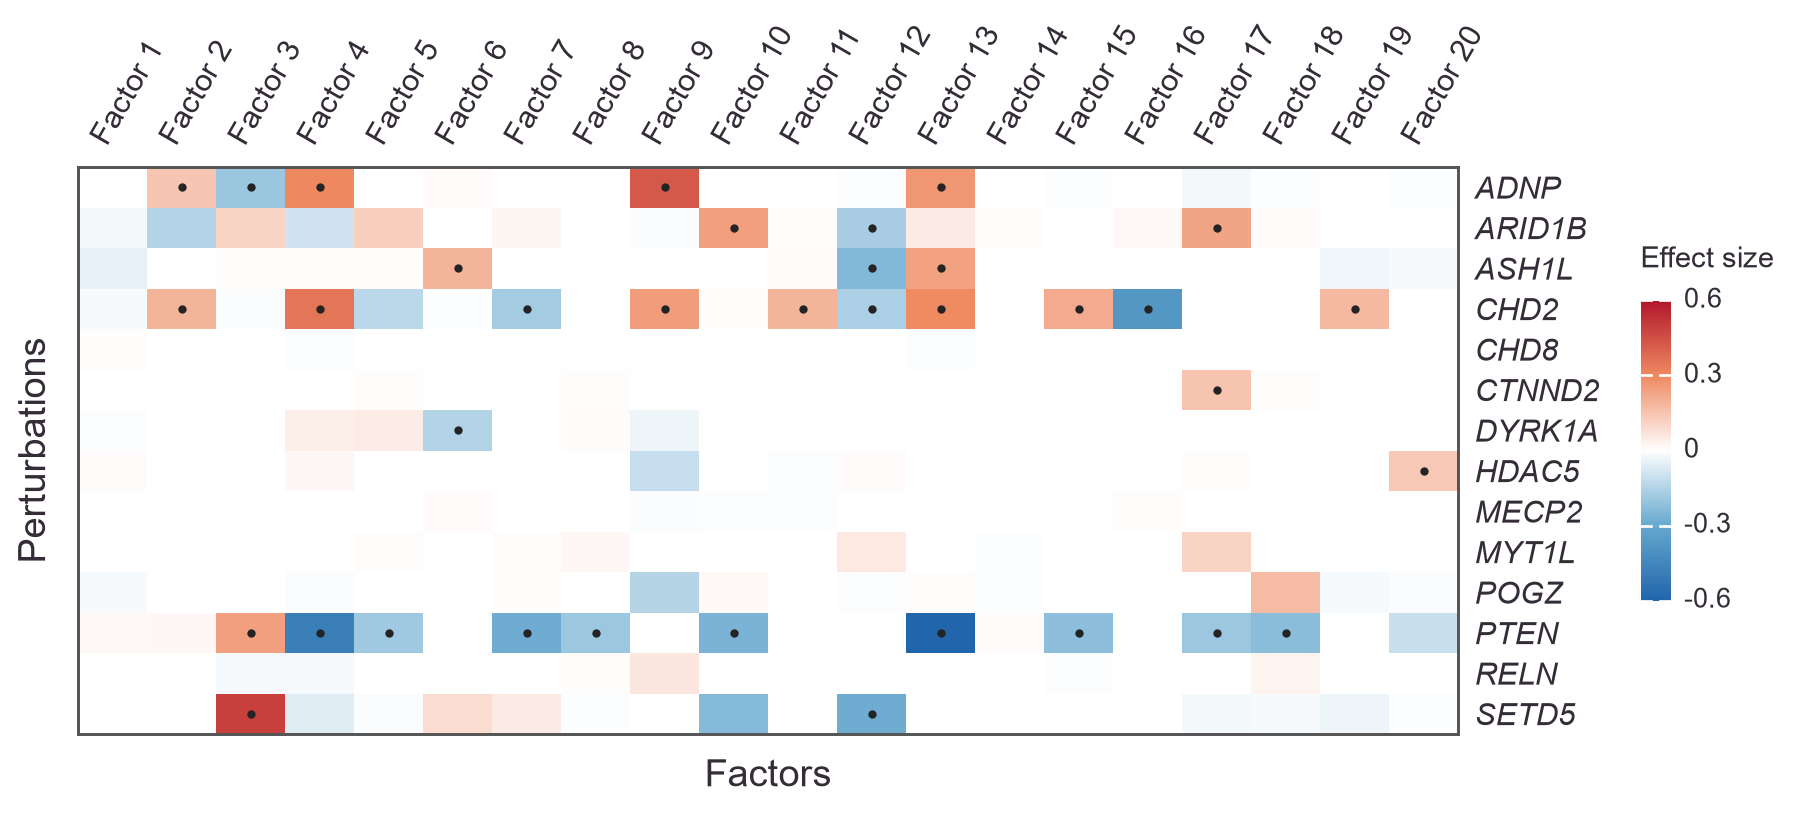

In [5]:
pip_b = pd.read_csv(result_dir / "PIP_B.csv", index_col=0)

fig = pp.plot_factor_effects(
    B,
    pip=pip_b, 
    show_significance=True, # set to True to show significance
  )

save(fig, "1_factor_effects_with_pip")

To show a subset:

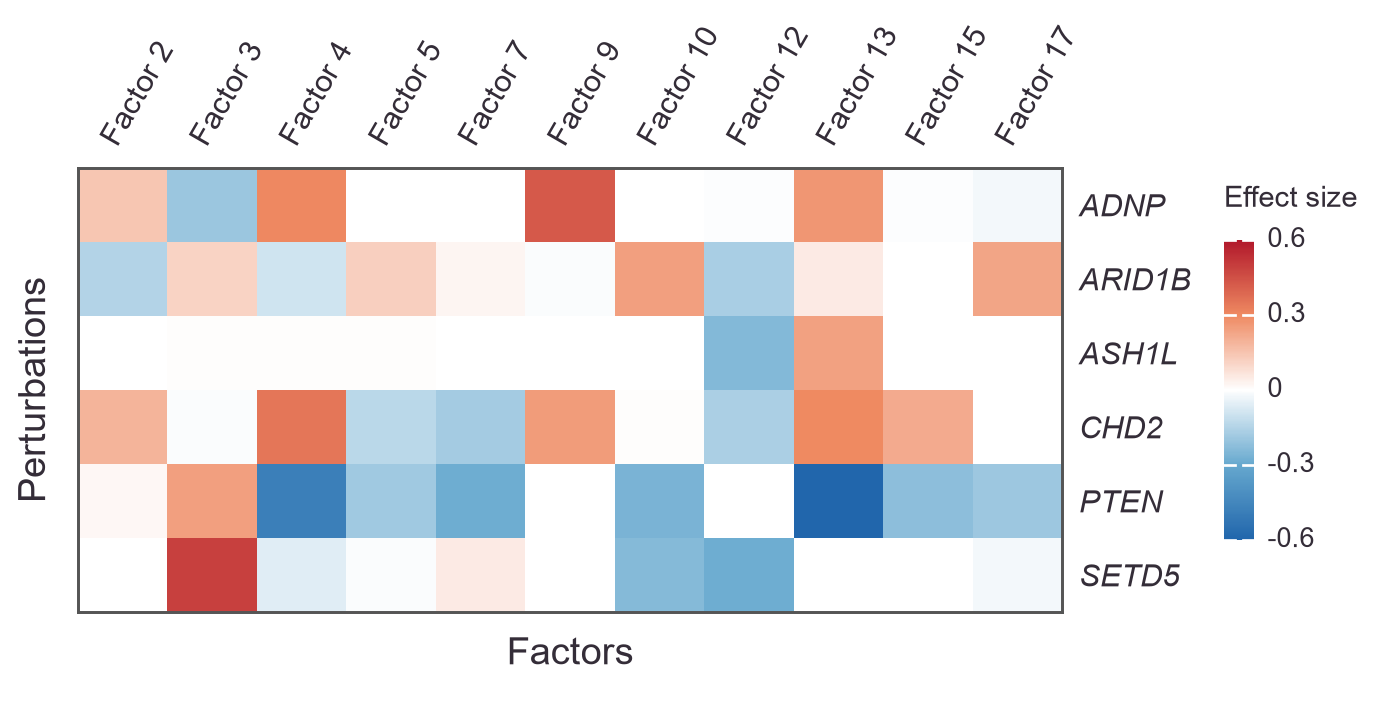

In [6]:
fig = pp.plot_factor_effects(
    B,
    perturbations=["ADNP", "ARID1B", "ASH1L", "CHD2", "PTEN", "SETD5"],
    # factor ID's zero-indexed, factor labels are one-indexed.
    factors=["factor_1", "factor_2", "factor_3", "factor_4", "factor_6", "factor_8",
             "factor_9", "factor_11", "factor_12", "factor_14", "factor_16"]
)
save(fig, "1_factor_effects_subset")

### 5. Gene loadings on factors

We provide curated annotation (`marker_annotations.csv`) for a subset of 30 marker genes.

- `gene_ID`: gene ID that matches with other files such as: `W.csv` and `BW.csv`.
- `gene_name`: display label, typically a gene symbol.
- `annotation`: category used for grouping and the legend.

Without annotations, plots will show gene IDs.

In [ ]:
annot = pd.read_csv(data_dir / "marker_annotations.csv")
ids = annot["gene_ID"].tolist()
print(annot.head(n=15))

            gene_ID gene_name                        annotation
0   ENSG00000183036      PCP4         neuron diff. / maturation
1   ENSG00000277586      NEFL         neuron diff. / maturation
2   ENSG00000143320    CRABP2         neuron diff. / maturation
3   ENSG00000131711     MAP1B         neuron diff. / maturation
4   ENSG00000162374    ELAVL4         neuron diff. / maturation
5   ENSG00000078018      MAP2         neuron diff. / maturation
6   ENSG00000166710       B2M  neg. reg. neuron differentiation
7   ENSG00000179218      CALR  neg. reg. neuron differentiation
8   ENSG00000138083      SIX3  neg. reg. neuron differentiation
9   ENSG00000135916     ITM2C  neg. reg. neuron projection dev.
10  ENSG00000196591     HDAC2  neg. reg. neuron projection dev.
11  ENSG00000072832     CRMP1  neg. reg. neuron projection dev.
12  ENSG00000108947     EFNB3  neg. reg. neuron projection dev.
13  ENSG00000170017     ALCAM     neuron projection development
14  ENSG00000075624      ACTB     neuron

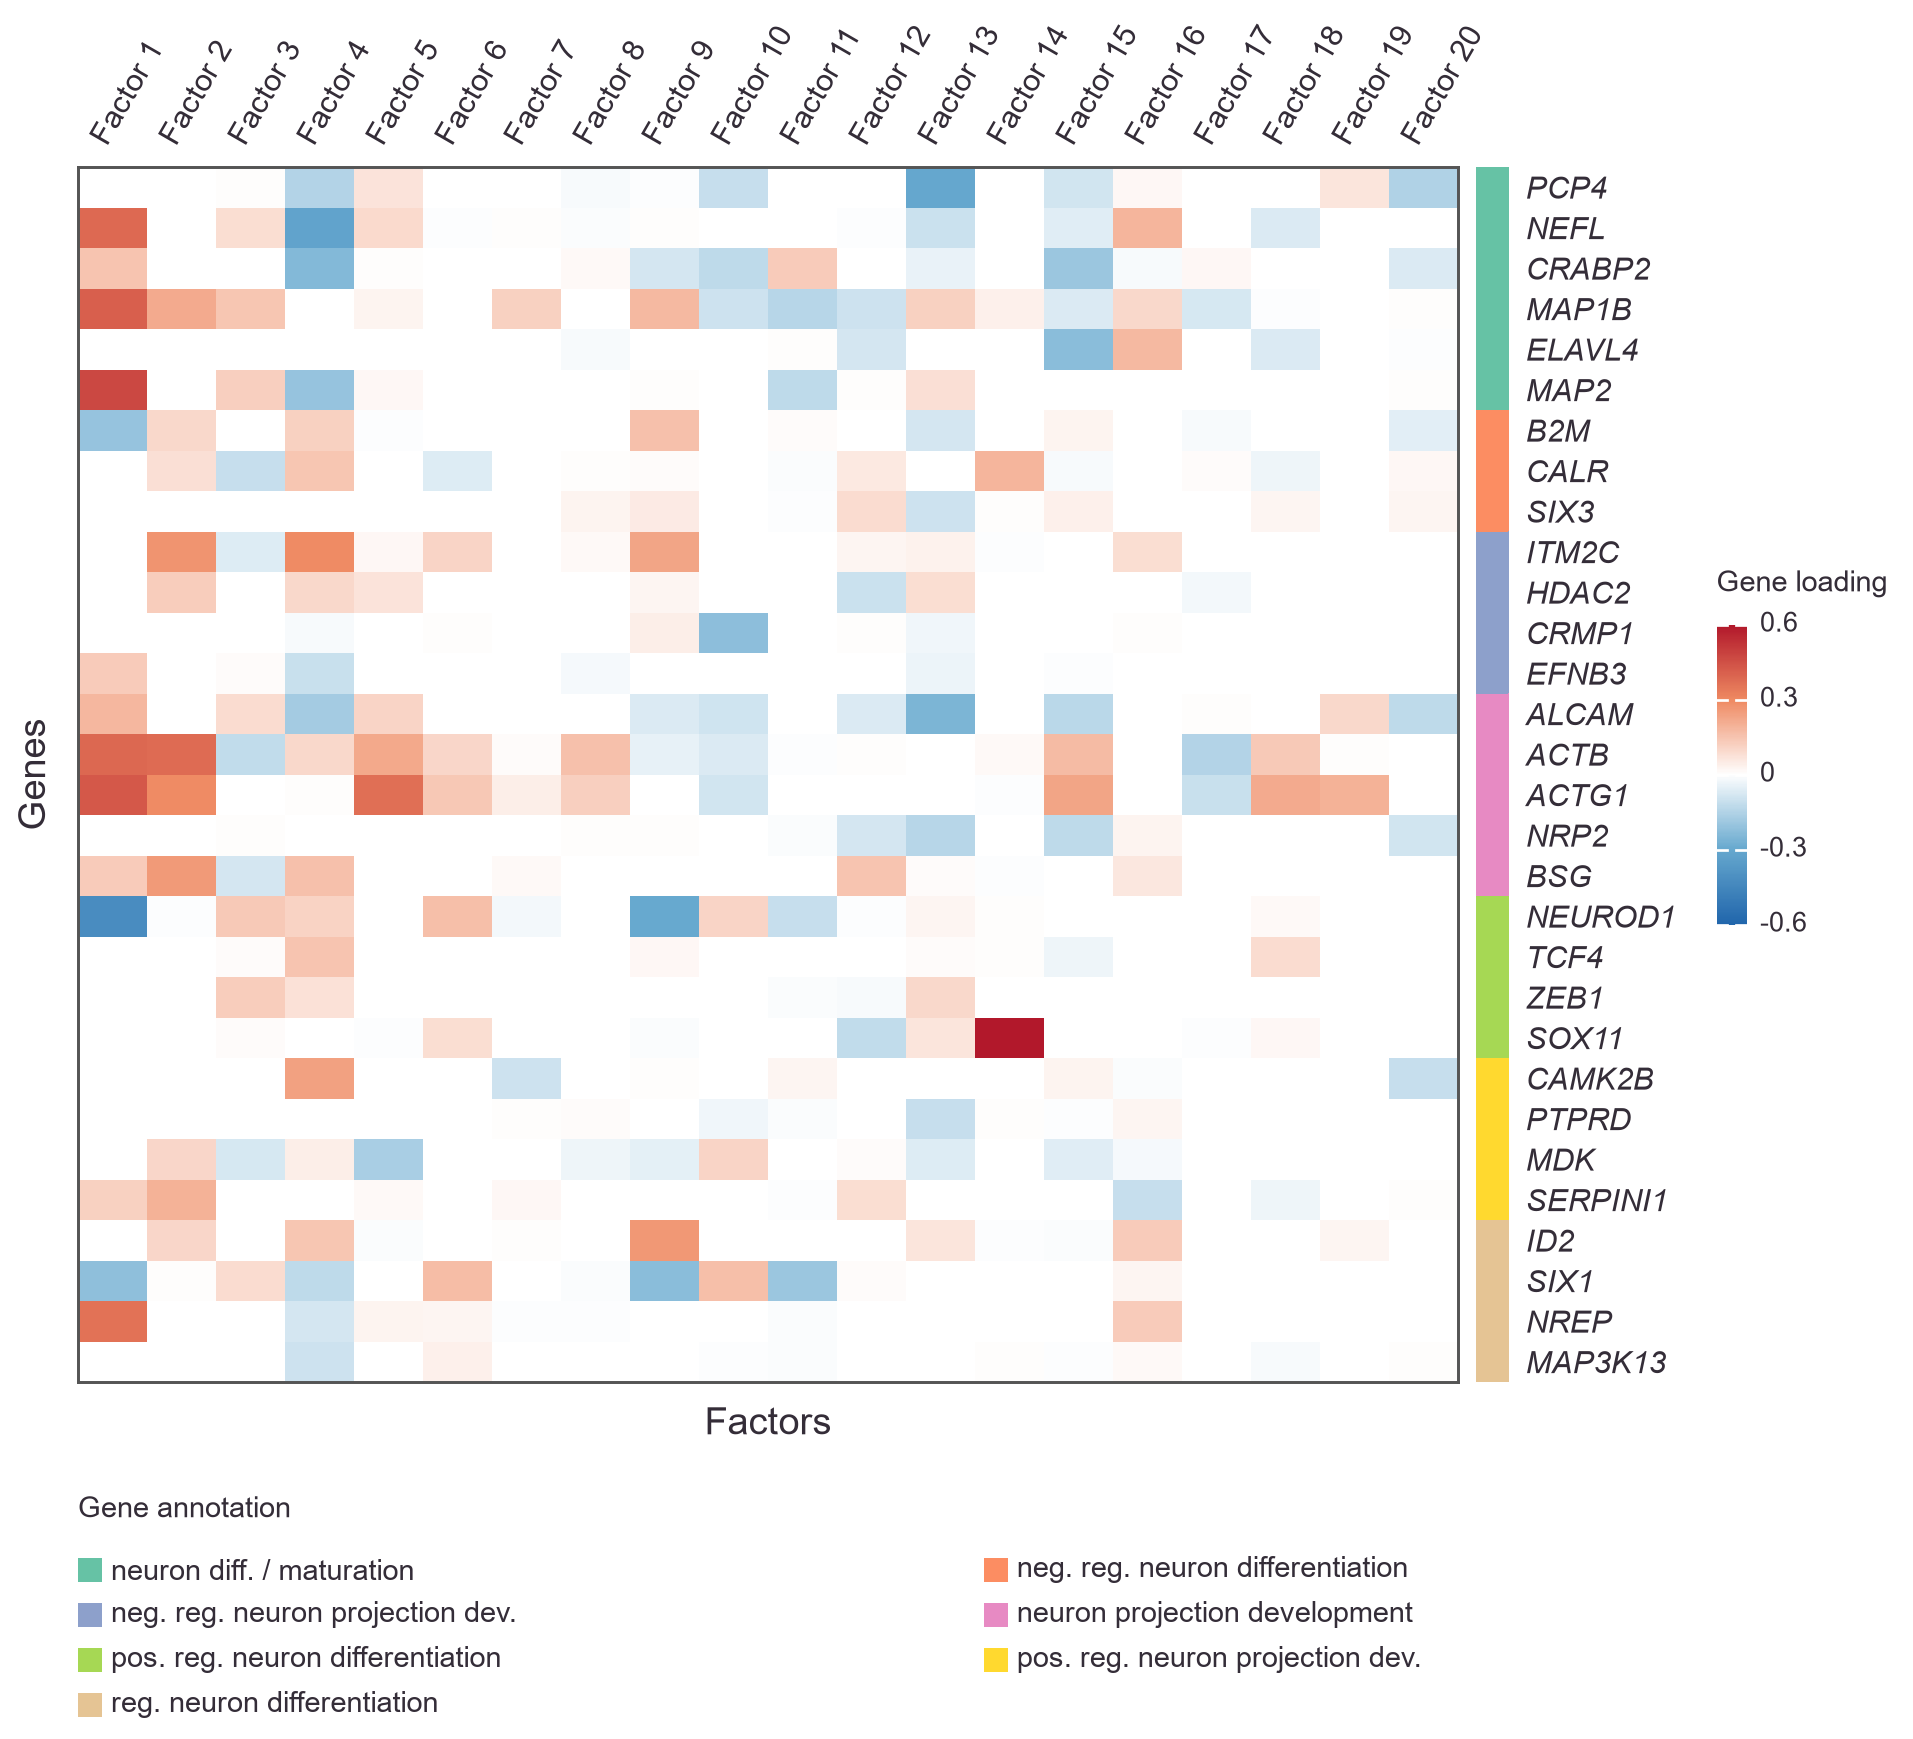

In [9]:
W = pd.read_csv(result_dir / "W.csv", index_col=0)
fig = pp.plot_gene_loadings(W, genes=ids, gene_annotations=annot)

save(fig, "2_gene_loadings_factors")

To show significance based on PIP > 0.95:

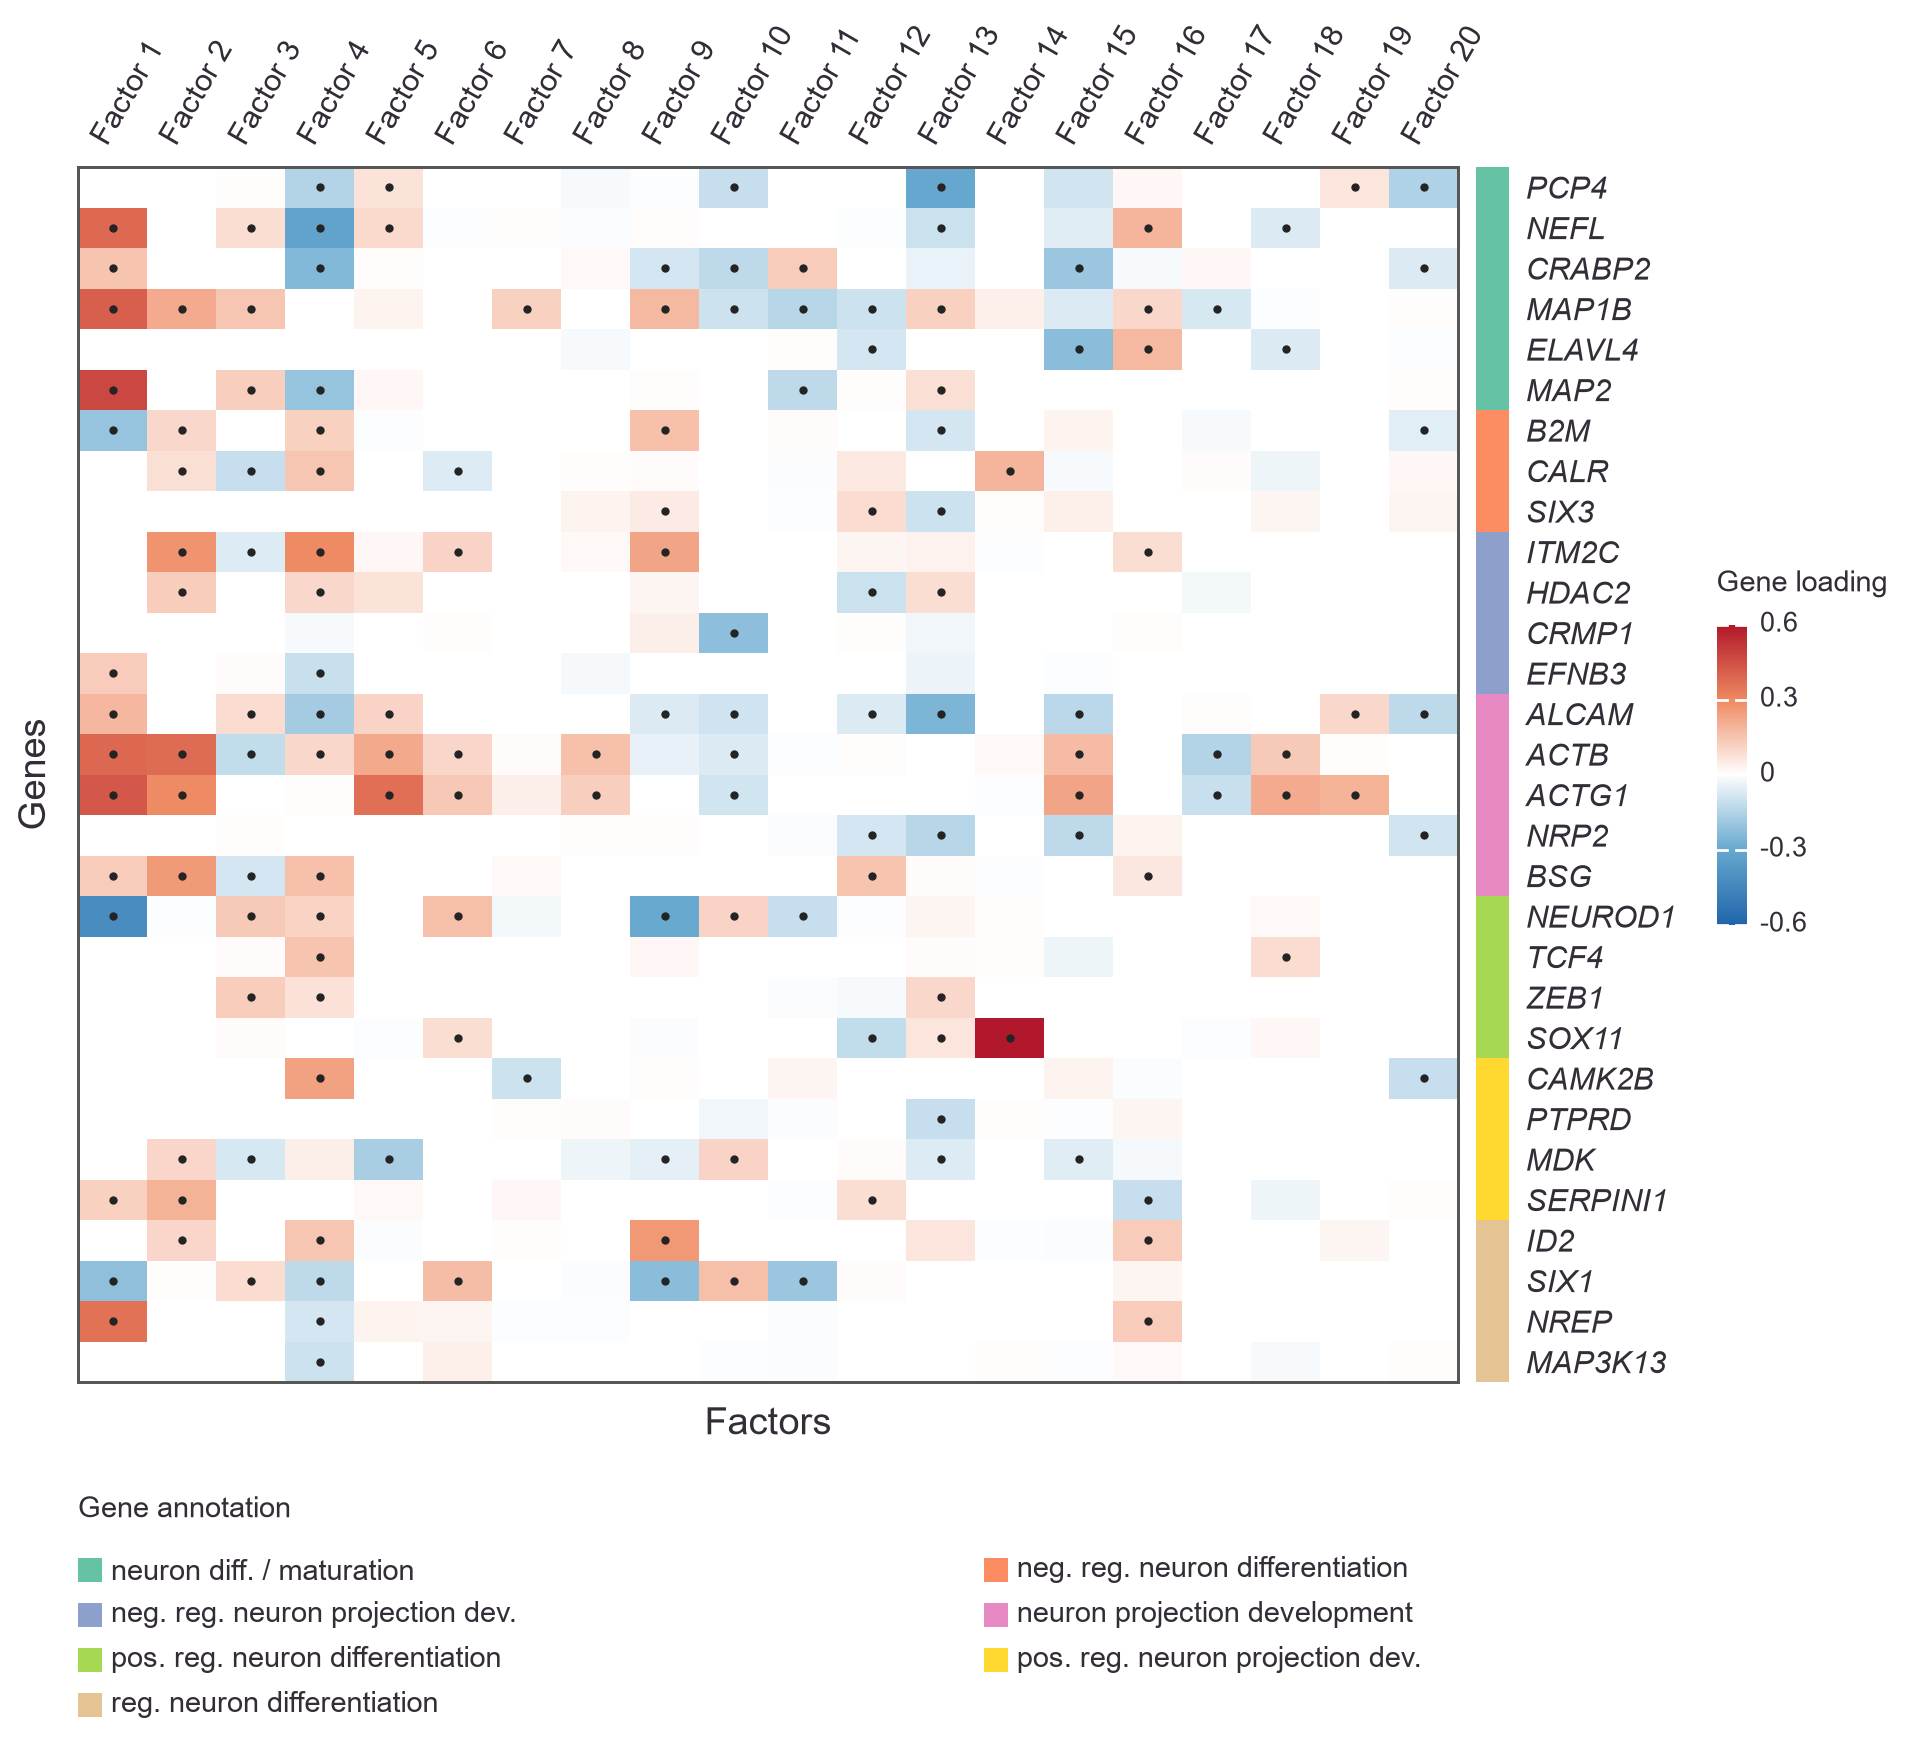

In [10]:
pip_w = pd.read_csv(result_dir / "PIP_W.csv", index_col=0)

fig = pp.plot_gene_loadings(
    W,
    genes=ids, gene_annotations=annot,
    pip=pip_w,
    show_significance=True, # set to True to show significance
  )

save(fig, "2_gene_loadings_factors_with_pip")

To show subset:

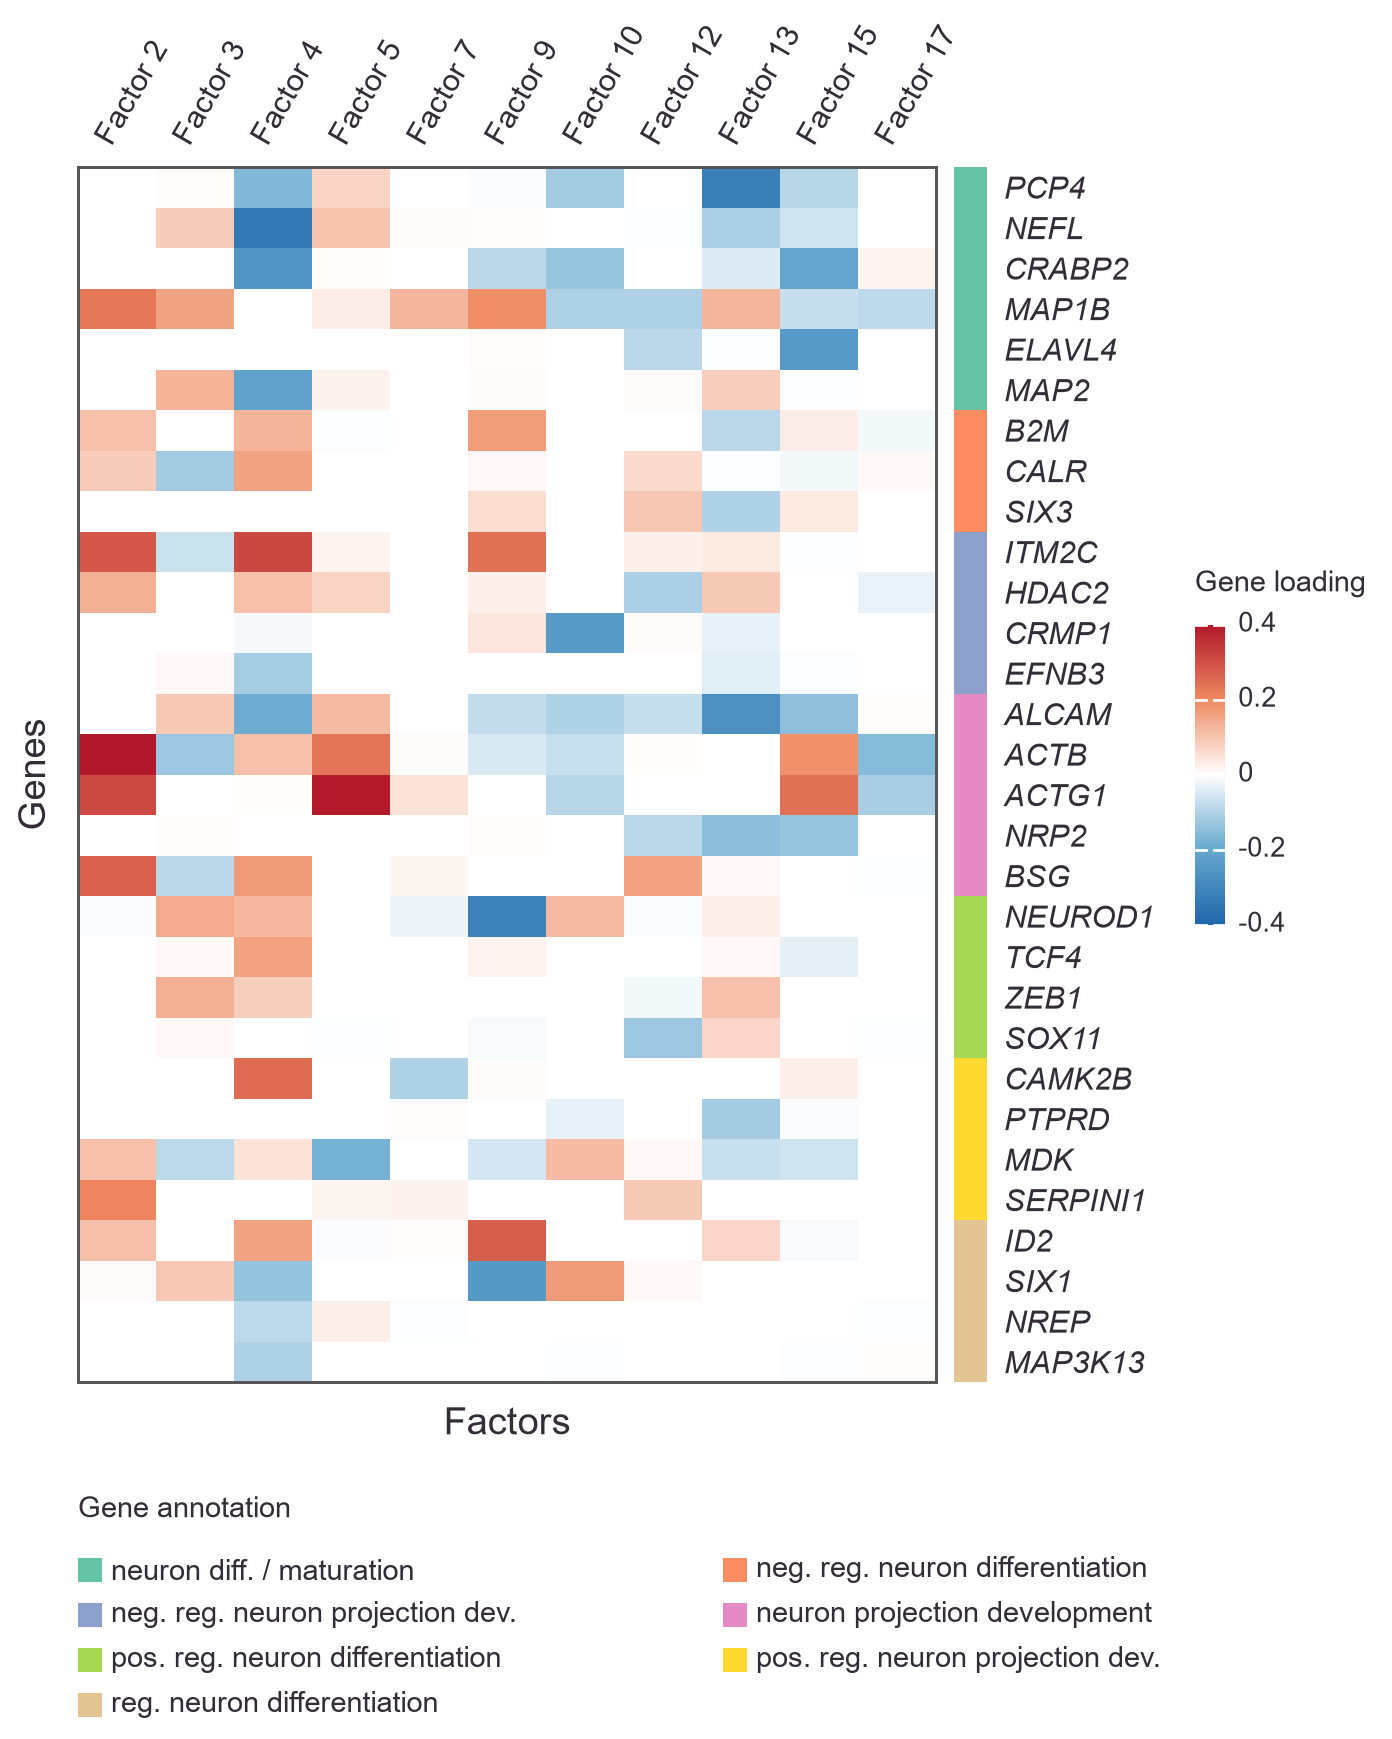

In [11]:
fig = pp.plot_gene_loadings(
    W, genes=ids, gene_annotations=annot,
    # factor ID's zero-indexed, factor labels are one-indexed
    factors=["factor_1", "factor_2", "factor_3", "factor_4", "factor_6", "factor_8",
             "factor_9", "factor_11", "factor_12", "factor_14", "factor_16"]
)

save(fig, "2_gene_loadings_factors_subset")

### 6. Overall perturbation effects

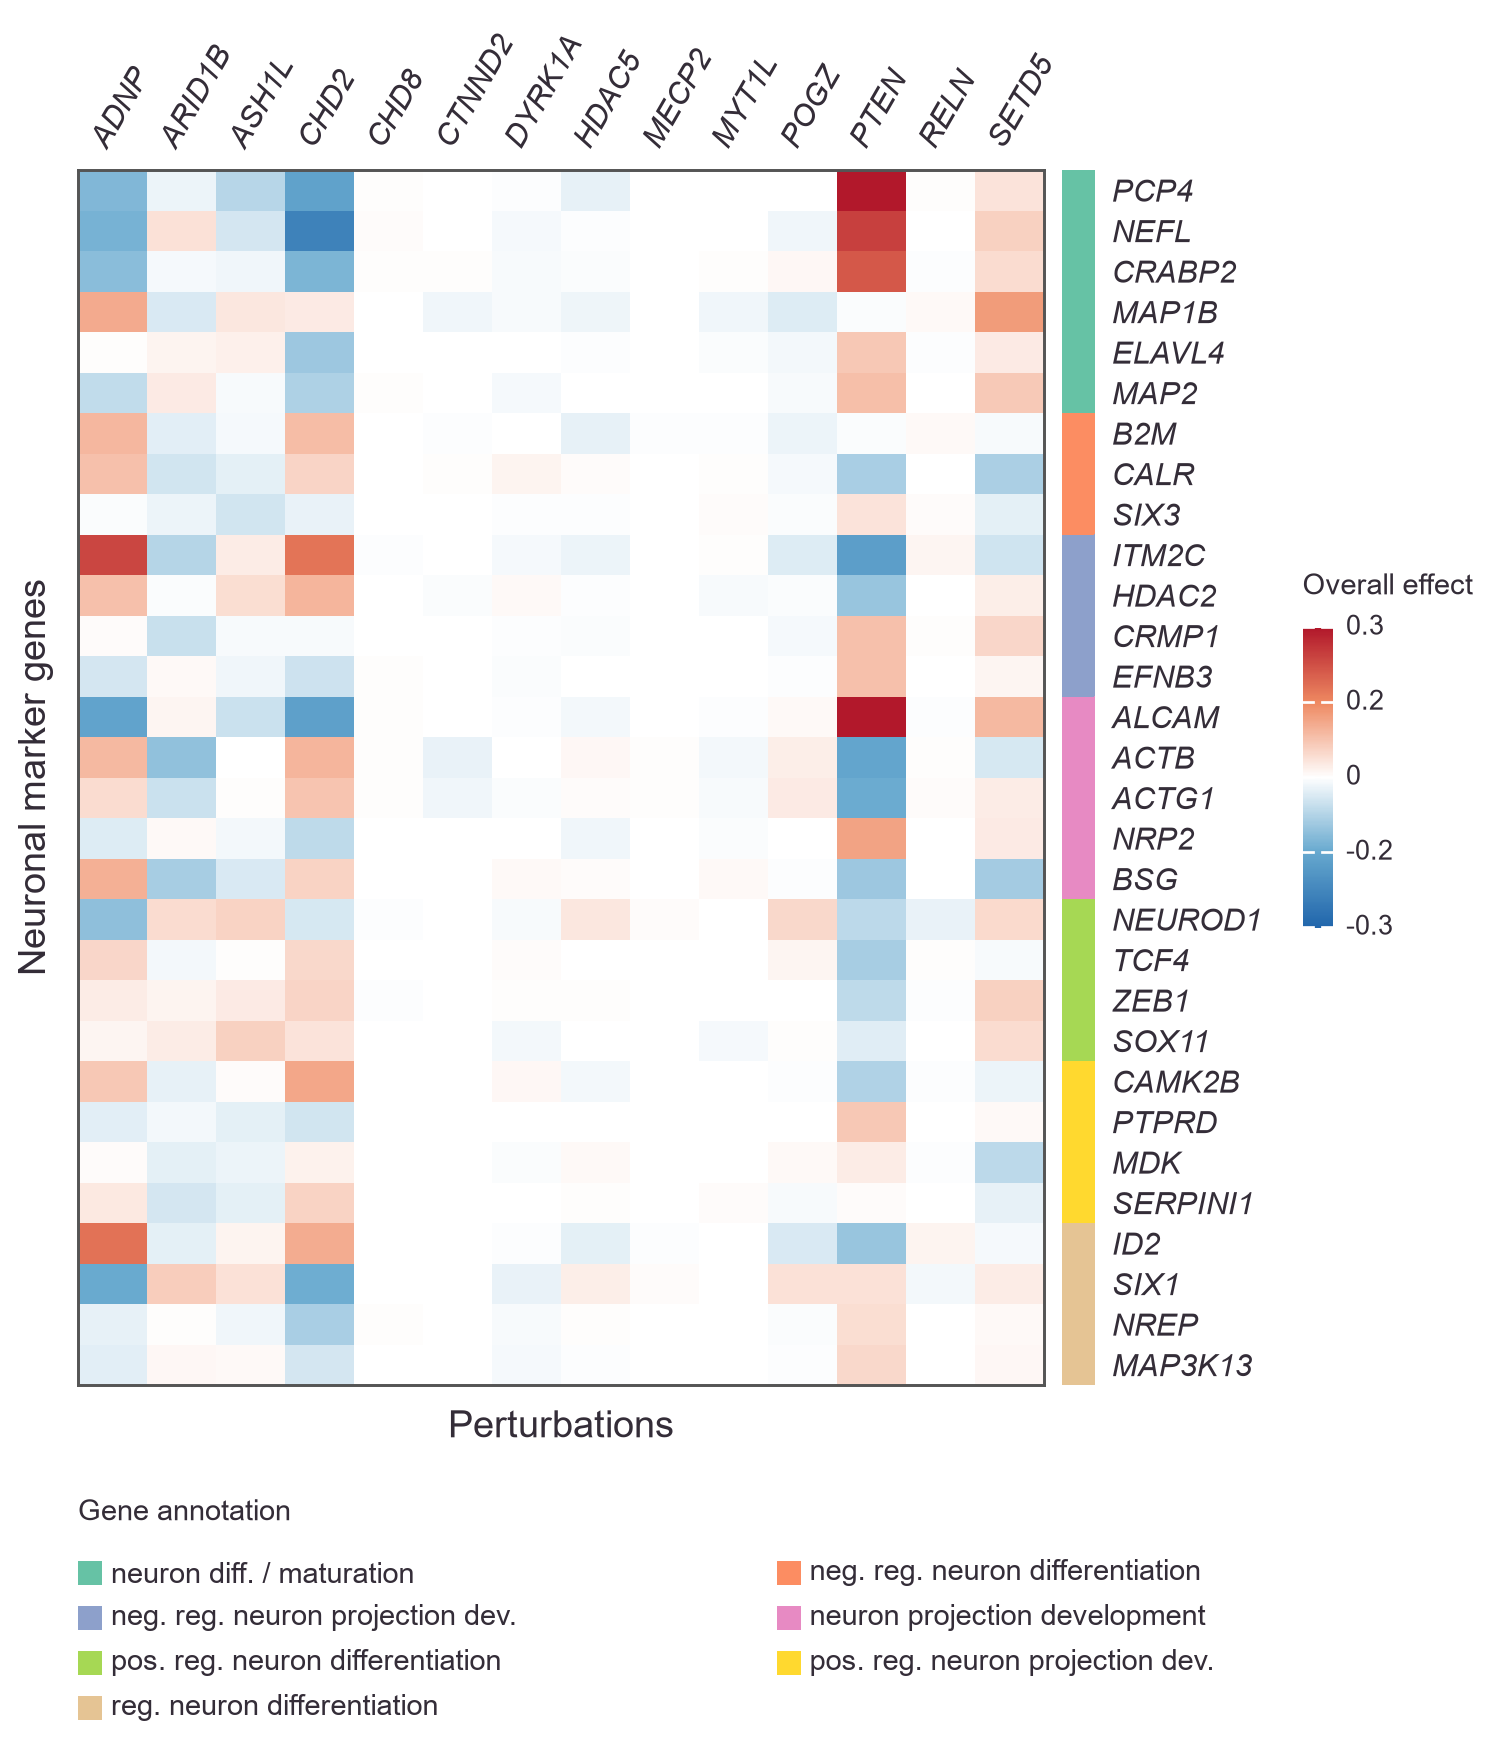

In [12]:
bw = pd.read_csv(result_dir / "BW.csv", index_col=0)
fig = pp.plot_gene_effects(bw, genes=ids, gene_annotations=annot)

fig.axes[0].set_ylabel("Neuronal marker genes")
save(fig, "3_overall_perturbation_effects")

To show significance based on LFSR < 0.05:

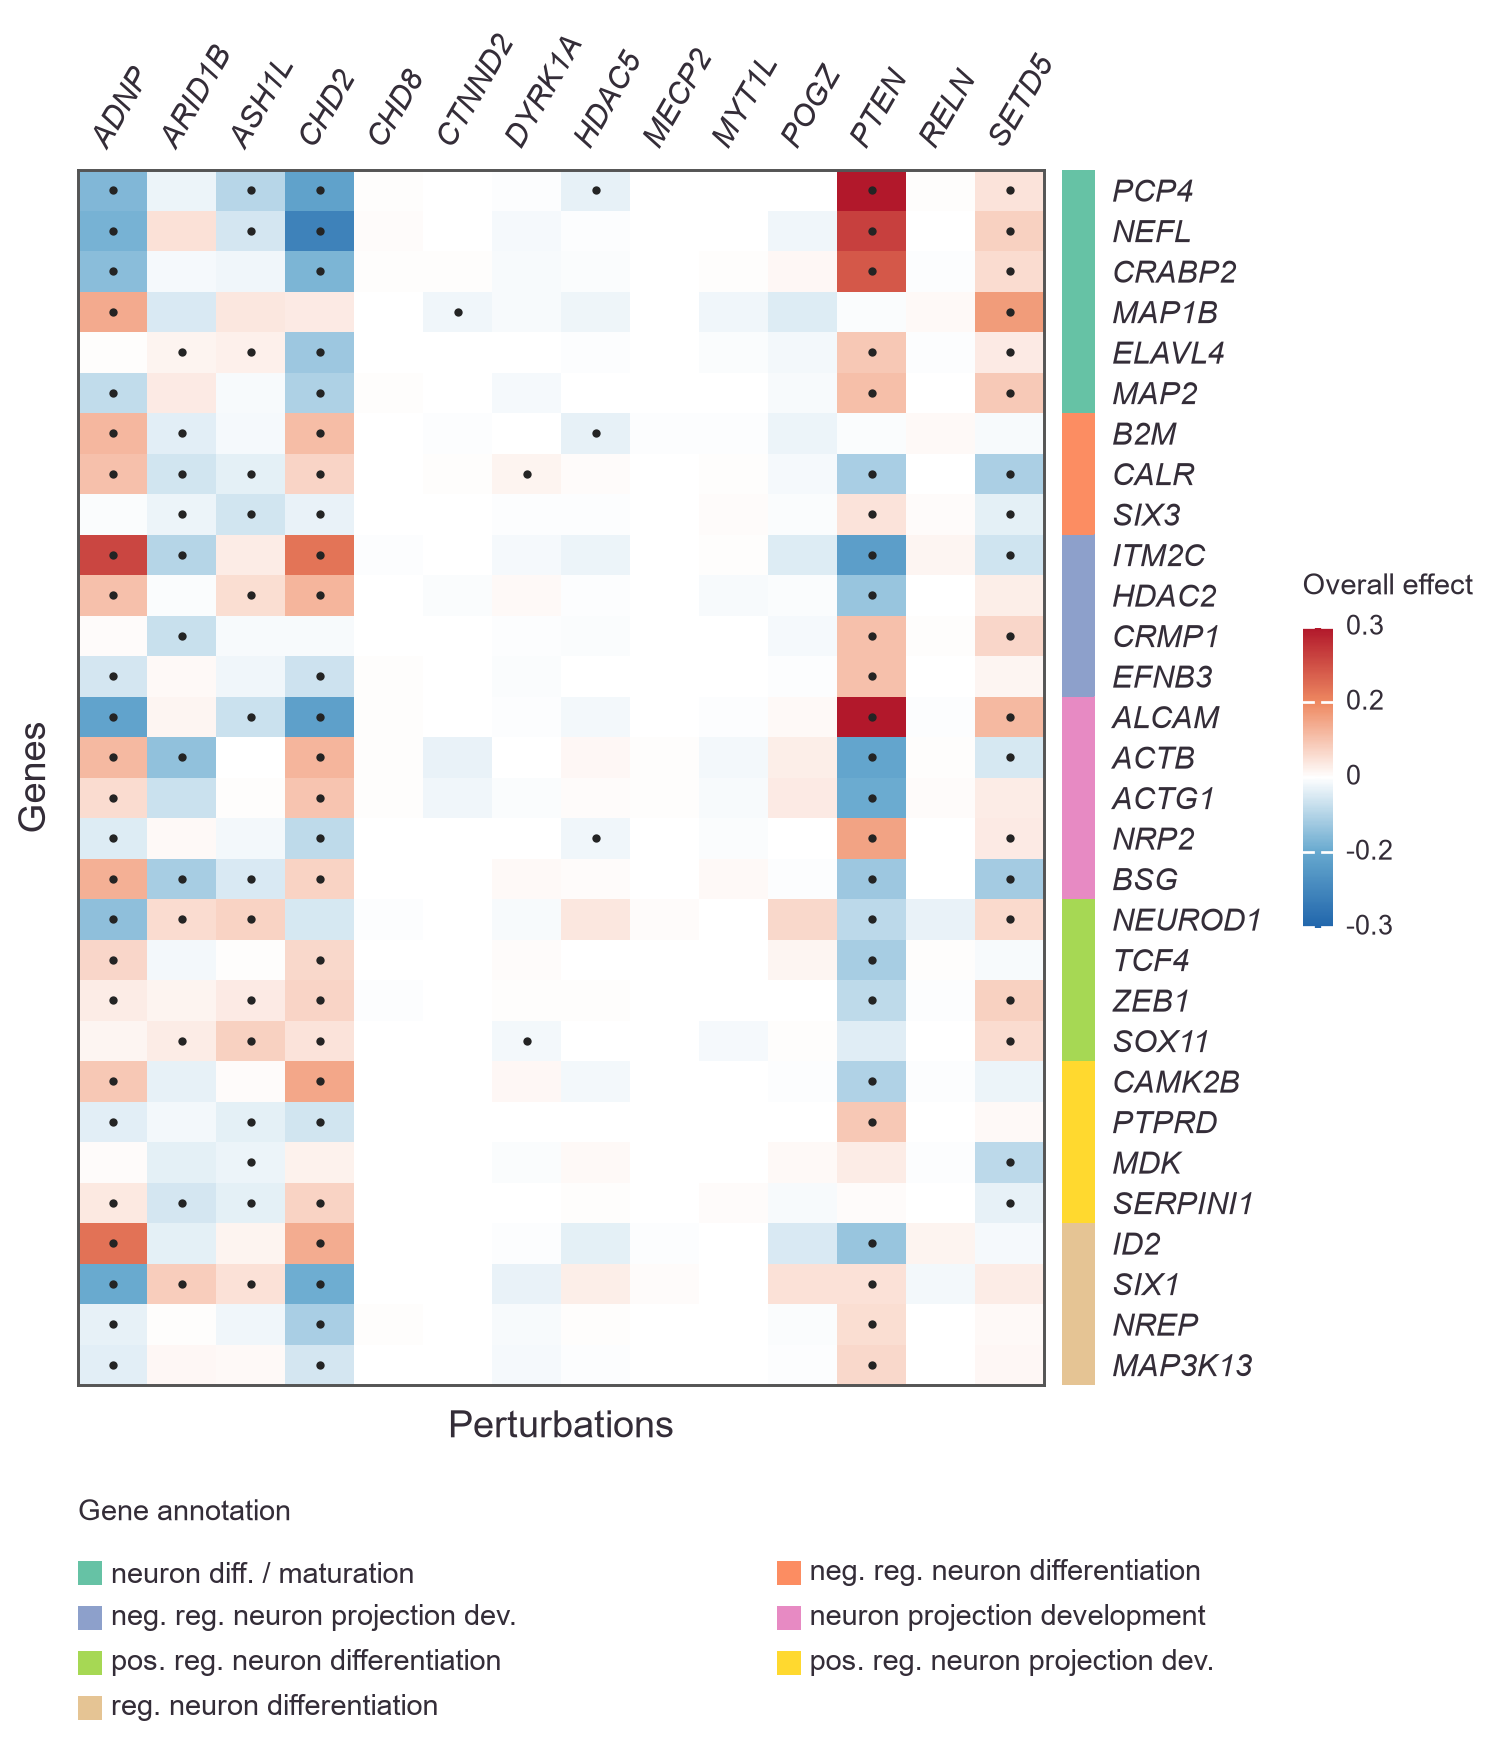

In [13]:
lfsr_bw = pd.read_csv(result_dir / "LFSR_BW.csv", index_col=0)

fig = pp.plot_gene_effects(
    bw,
    genes=ids, gene_annotations=annot,
    lfsr=lfsr_bw, show_significance=True, # set to True
)

save(fig, "3_overall_perturbation_effects_with_lfsr")

To show a subset:

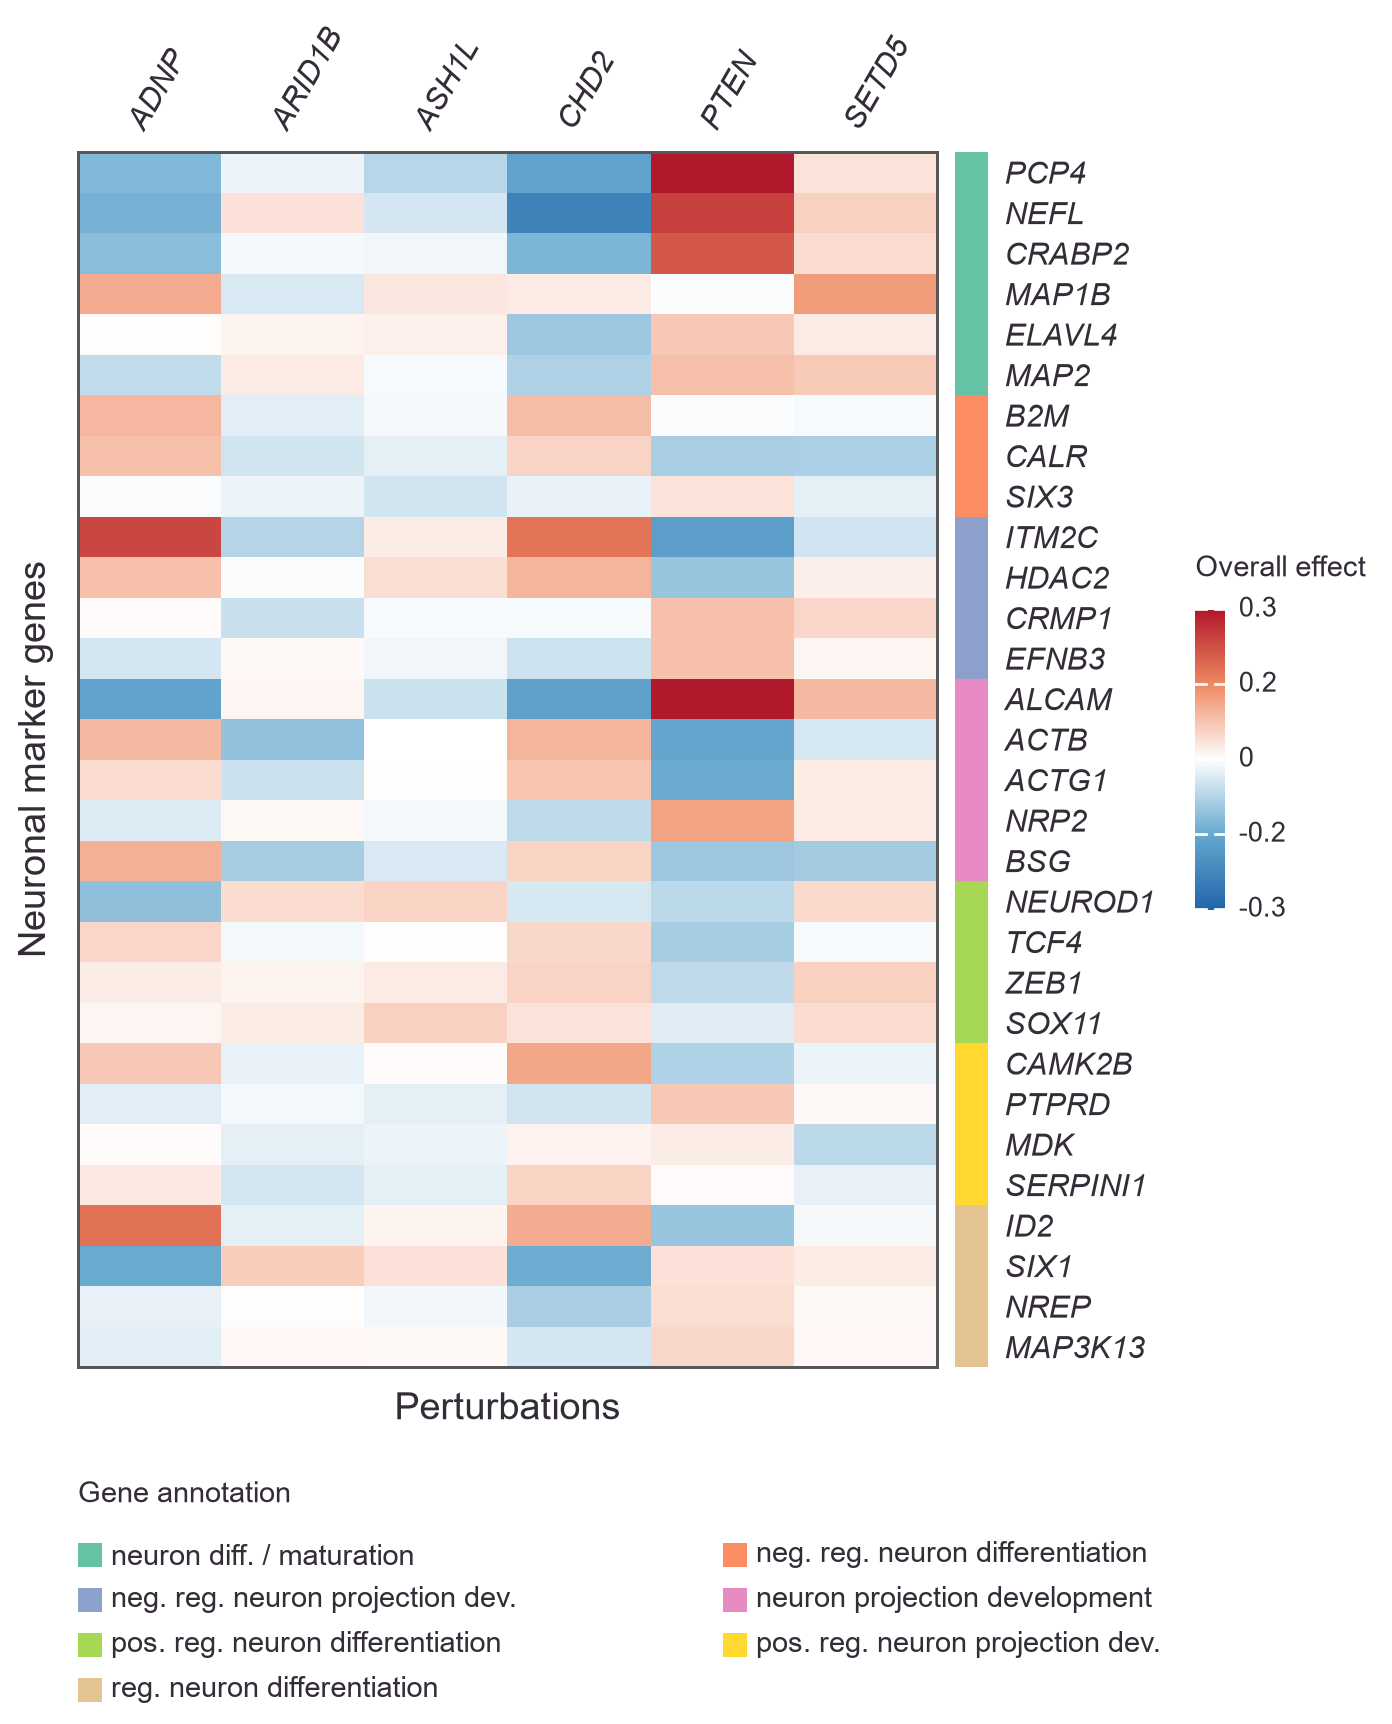

In [14]:
fig = pp.plot_gene_effects(
    bw, 
    genes=ids, gene_annotations=annot,
    perturbations=["ADNP", "ARID1B", "ASH1L", "CHD2", "PTEN", "SETD5"]
)

fig.axes[0].set_ylabel("Neuronal marker genes")
save(fig, "3_overall_perturbation_effects_subset")

### 7. Genes with loading PIP > 0.95 per factor

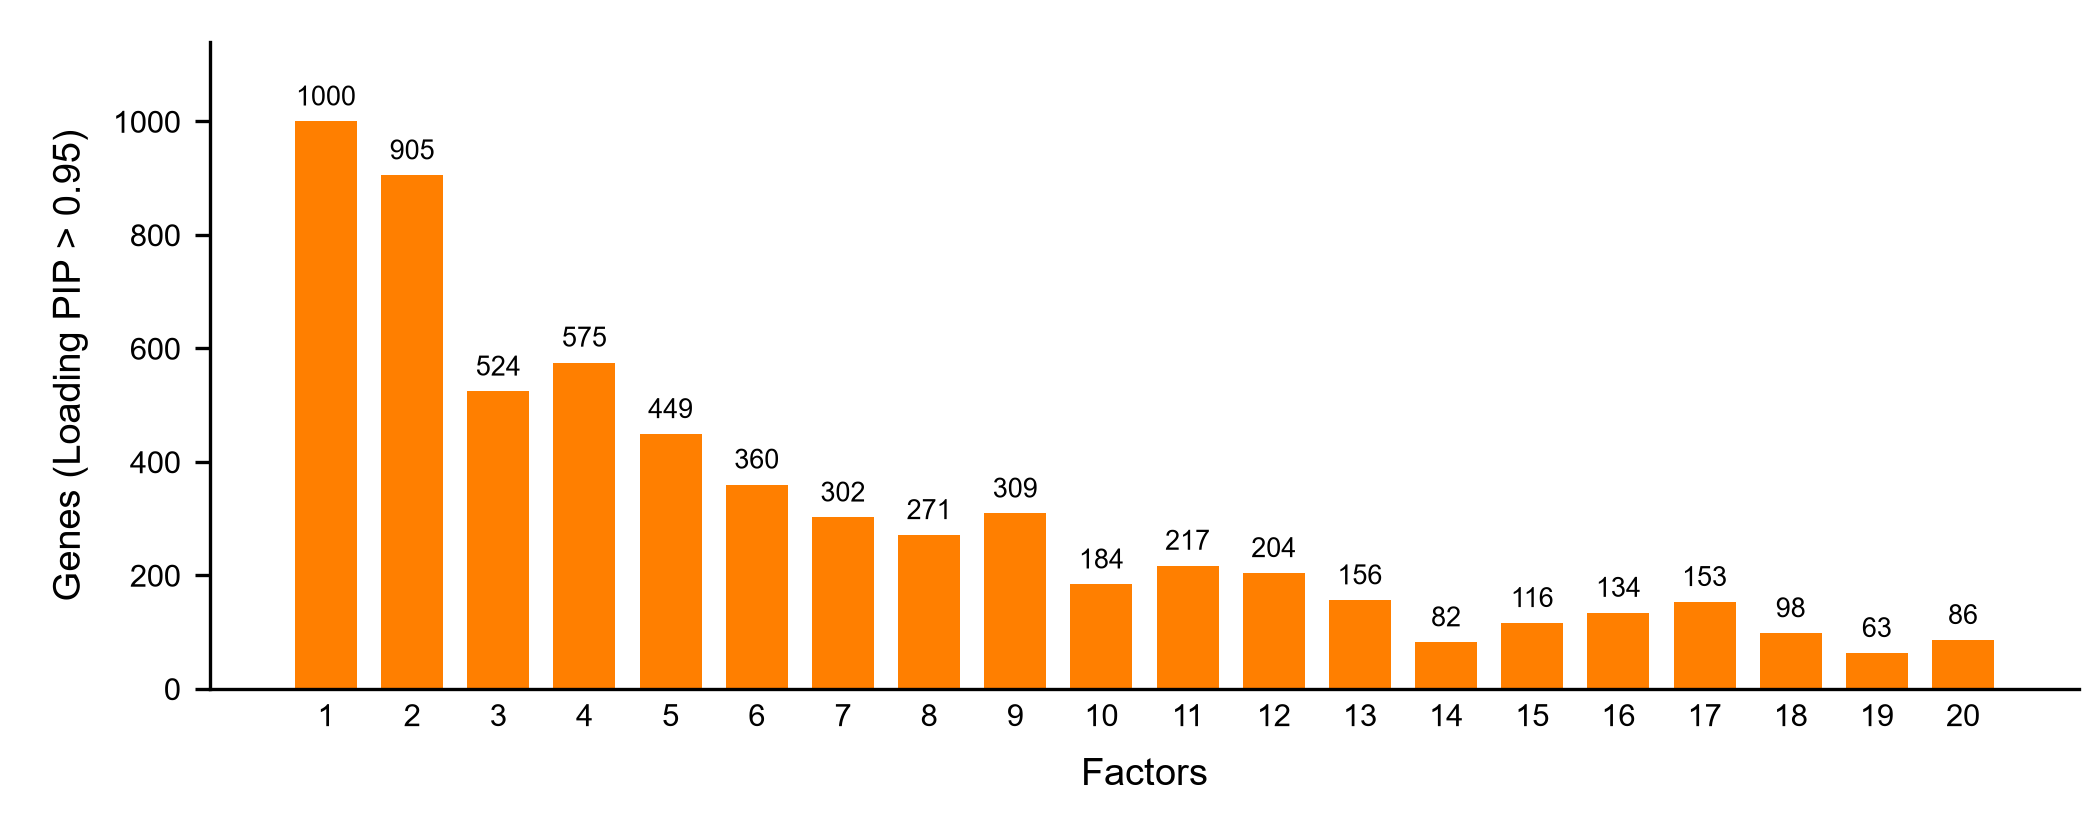

In [15]:
high_pip_genes = (pip_w > 0.95).sum(axis=1)

# one-indexed factor labels
factor_labels = [str(int(factor.removeprefix("factor_")) + 1)
                 for factor in high_pip_genes.index]
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.bar(factor_labels, high_pip_genes.values, color="#FF7F00", width=0.72)
ax.set(xlabel="Factors", ylabel="Genes (Loading PIP > 0.95)")
peak = max(high_pip_genes.max(), 1)
ax.set_ylim(0, 1.14 * peak)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", length=0, labelsize=7.5)
ax.tick_params(axis="y", labelsize=7.5)
ax.xaxis.label.set_fontsize(9)
ax.yaxis.label.set_fontsize(9)
ax.xaxis.labelpad = ax.yaxis.labelpad = 6
for i, value in enumerate(high_pip_genes):
    ax.text(i, value + 0.018 * peak, str(value),
            ha="center", va="bottom", fontsize=6.5)
fig.subplots_adjust(left=0.10, right=0.99, bottom=0.18, top=0.95)

save(fig, "4_high_pip_genes_per_factor")

### 8. DEGs (LFSR < 0.05) per perturbation

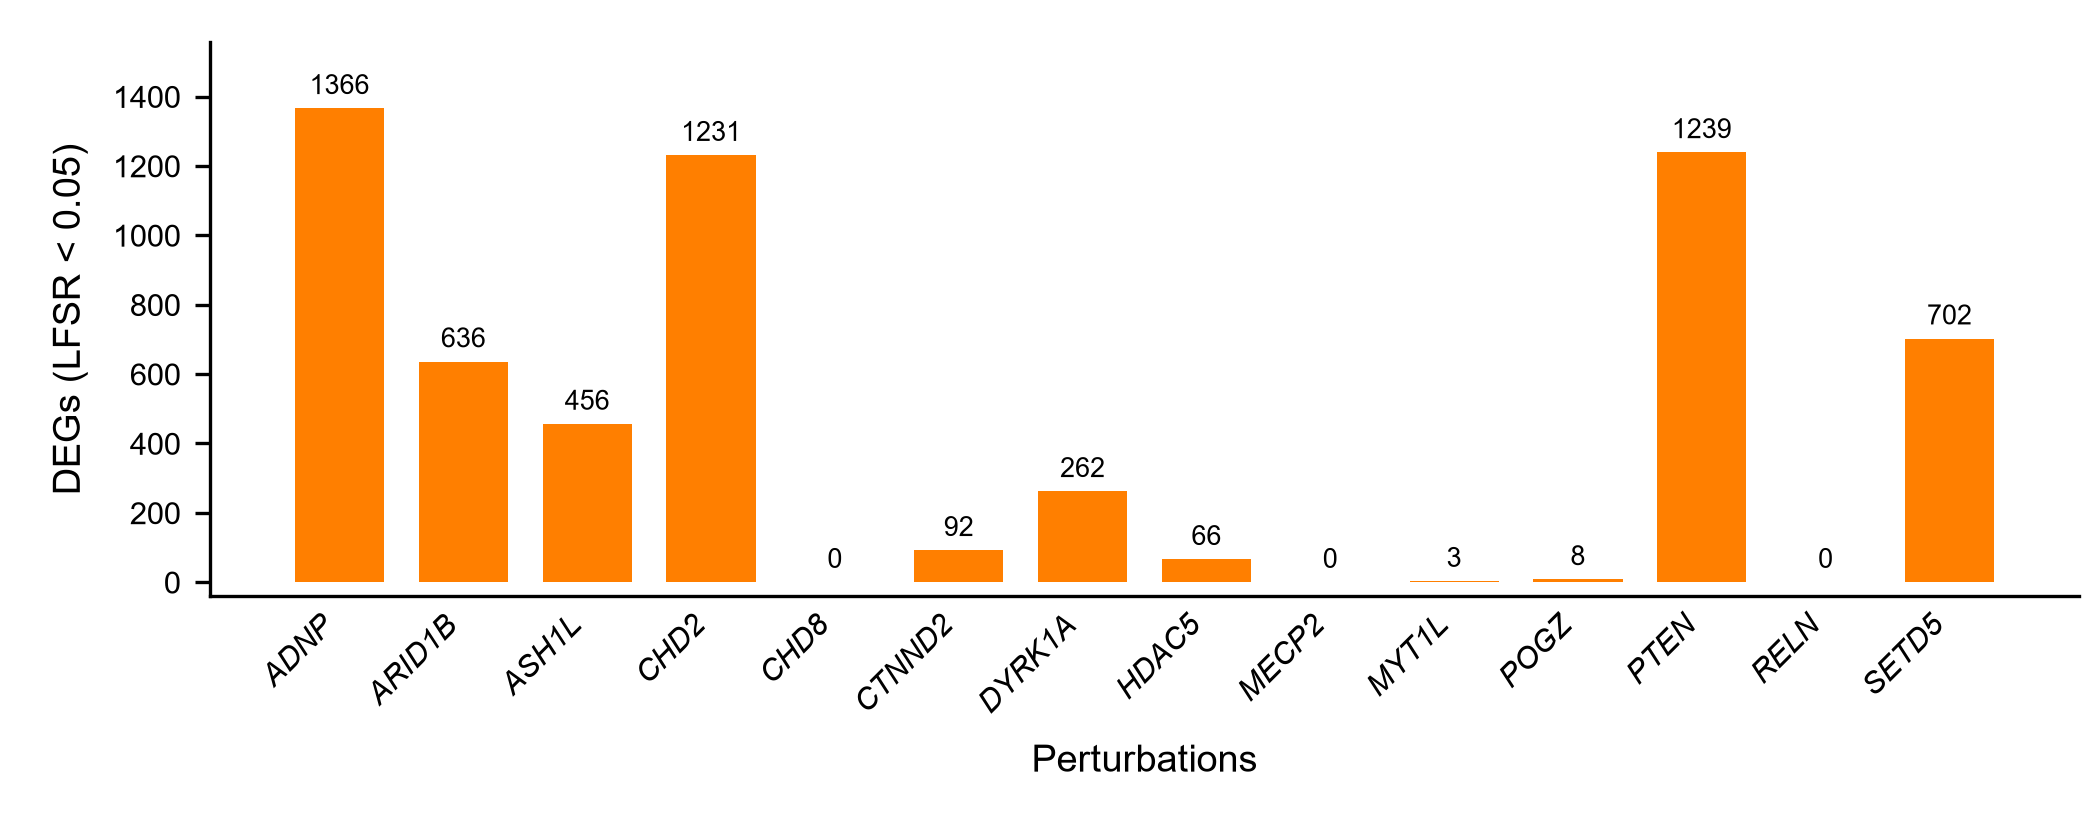

In [16]:
degs = (lfsr_bw < 0.05).sum(axis=1)

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.bar(degs.index, degs.values, color="#FF7F00", width=0.72)
ax.set(xlabel="Perturbations", ylabel="DEGs (LFSR < 0.05)")
ax.set_ylim(-0.03 * max(degs), 1.14 * max(degs))
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", rotation=45, length=0, labelsize=7.5)
ax.tick_params(axis="y", labelsize=7.5)
for tick in ax.get_xticklabels():
    tick.set(ha="right", fontstyle="italic")
ax.xaxis.label.set_fontsize(9)
ax.yaxis.label.set_fontsize(9)
ax.xaxis.labelpad = ax.yaxis.labelpad = 6
for i, value in enumerate(degs):
    ax.text(i, value + 0.018 * max(degs), str(value),
            ha="center", va="bottom", fontsize=6.5)
fig.subplots_adjust(left=0.10, right=0.99, bottom=0.29, top=0.95)

save(fig, "5_degs_per_perturbation")

### 9. GO Enrichment Analysis

Here, we test genes with loading PIP > 0.95 per factor for GO Biological Process over-representation against all 6,000 modeled genes using `WebGestaltR` (v1.0.1), with terms considered significant at BH-adjusted FDR < 0.05. The GO annotation snapshot was frozen at 2026-09-06 for reproducibility.

```r
WebGestaltR::WebGestaltR(
  enrichMethod = "ORA",
  organism = "hsapiens",
  # use the frozen annotation
  enrichDatabaseFile = "input/frozen_annotation/go_bp_noRedundant.gmt",
  enrichDatabaseDescriptionFile = "input/frozen_annotation/go_bp_noRedundant.des",
  enrichDatabaseType = "entrezgene",
  # or, the live annotation, 
  # enrichDatabase = "geneontology_Biological_Process_noRedundant",
  interestGene = foreground,
  interestGeneType = "ensembl_gene_id",
  referenceGene = background,
  referenceGeneType = "ensembl_gene_id",
  minNum = 10,
  maxNum = 500,
  fdrMethod = "BH",
  sigMethod = "fdr",
  fdrThr = 0.05,
  isOutput = FALSE
)
```
See [`run_factor_enrichment.R`](https://github.com/mancusolab/perturbvi_analysis/blob/main/2_luhmes/run_factor_enrichment.R).
<br/>
The enrichment result is saved at `input/factor_enrichment.csv`.


Next, we filter the neuronal terms and plot the enrichment.
<br/>
See [`plot_factor_enrichment.R`](https://github.com/mancusolab/perturbvi_analysis/blob/main/2_luhmes/plot_factor_enrichment.R).

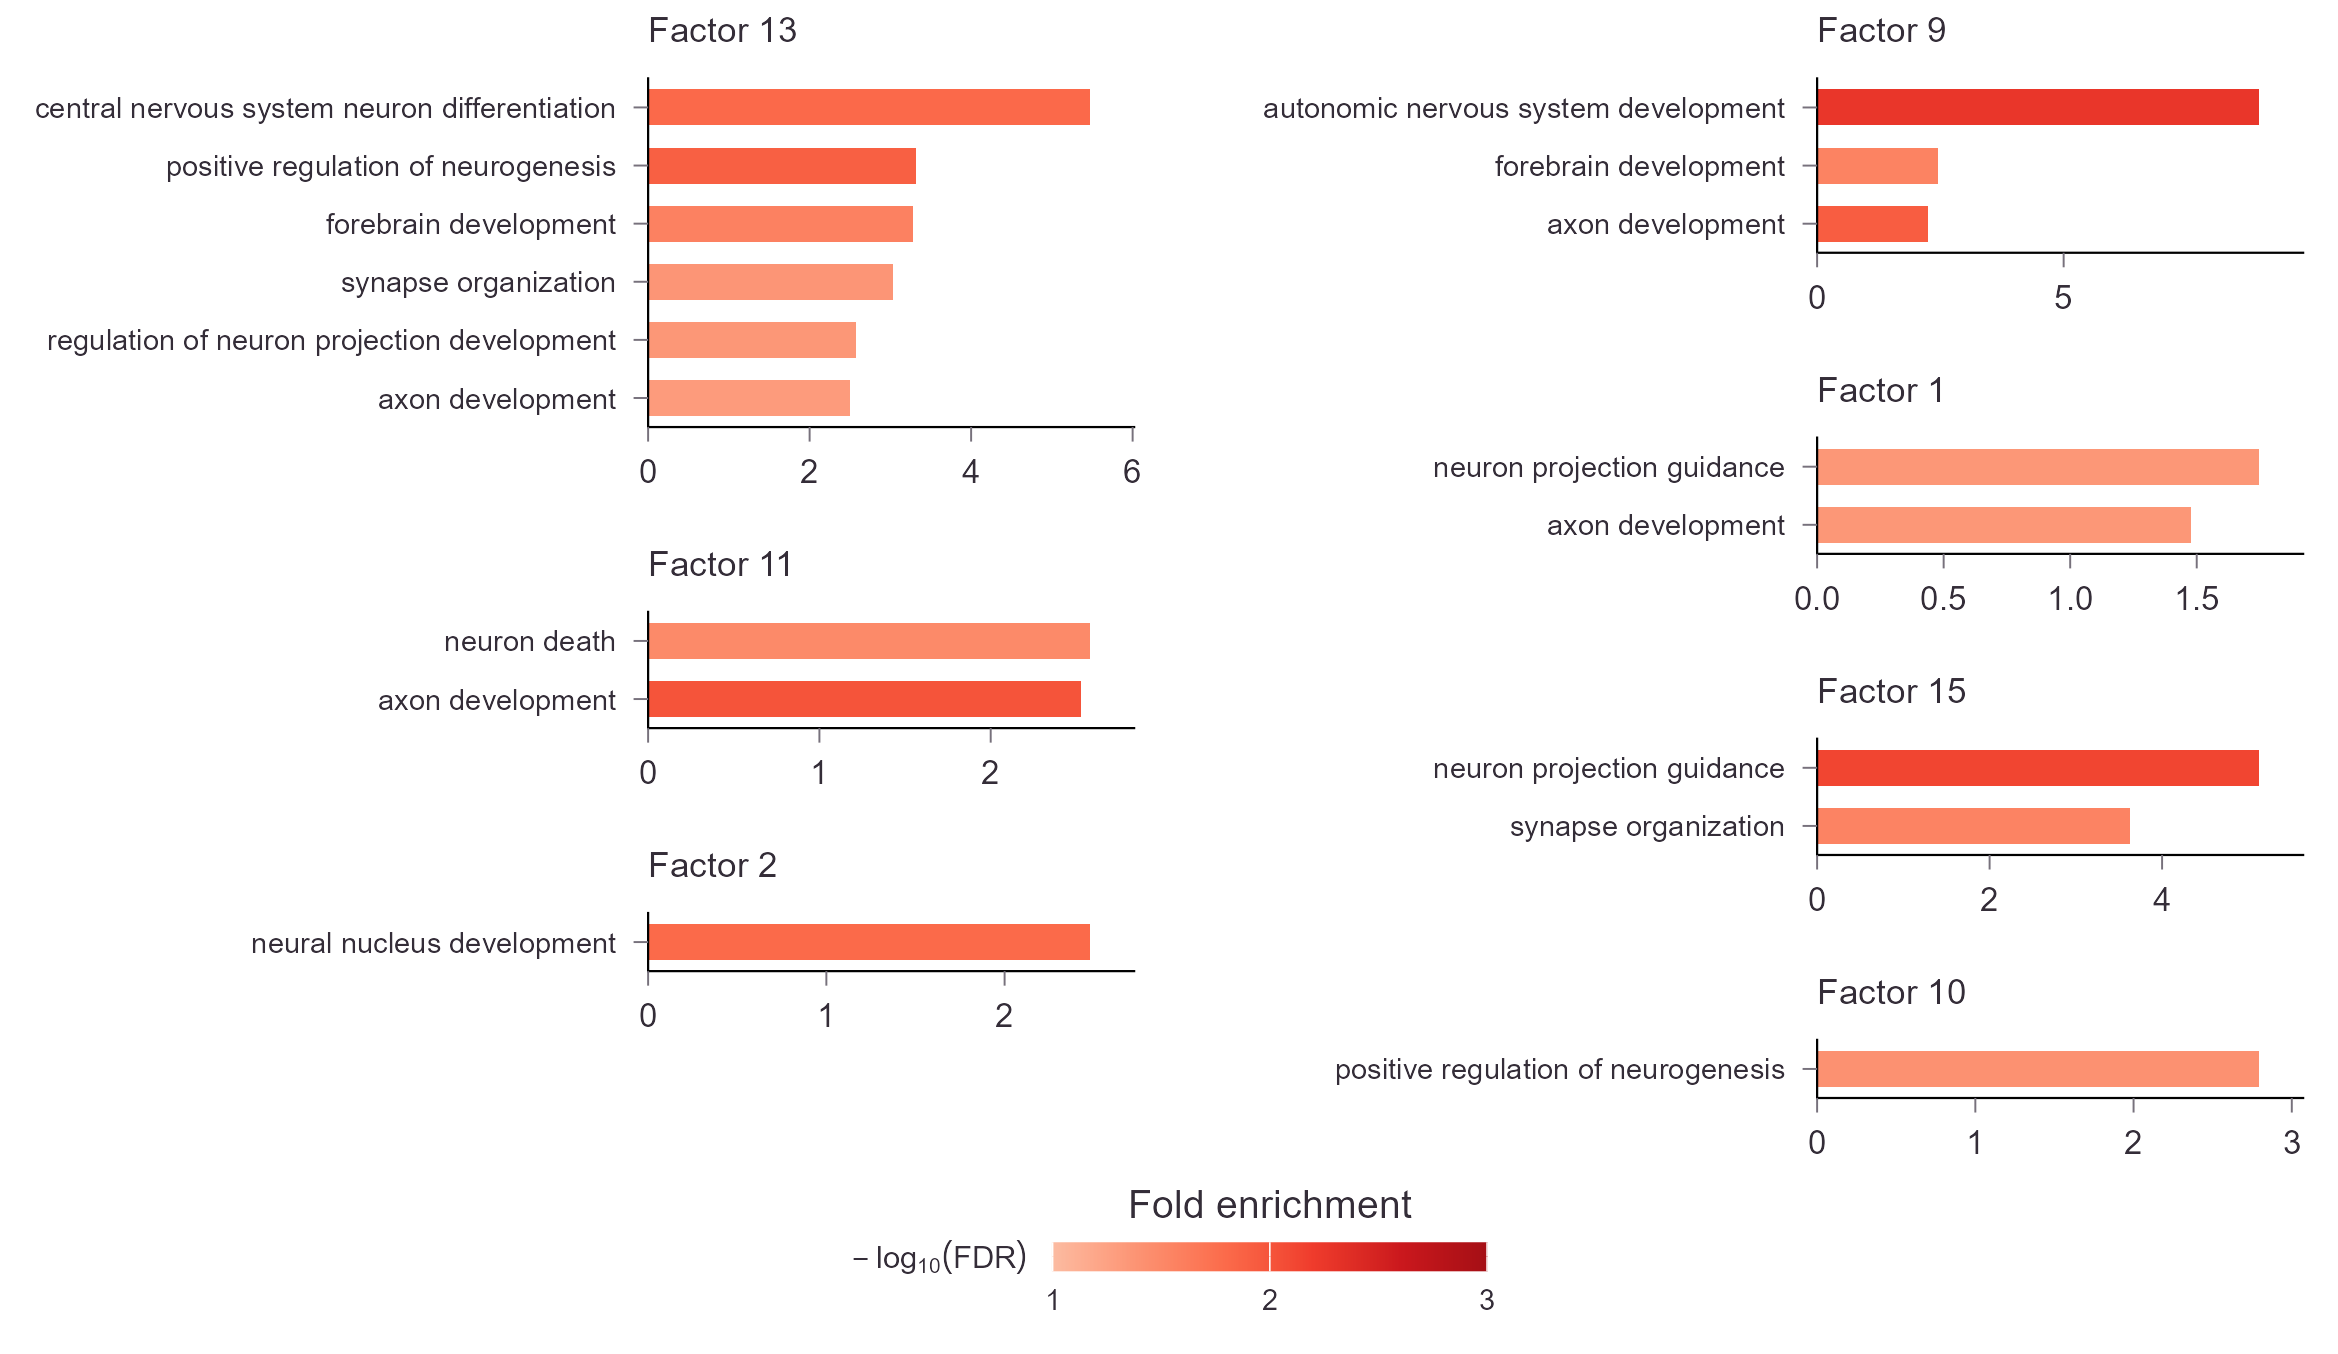

In [18]:
display(Image(filename="figures/6_neuronal_factor_enrichment.png"))

Across the 20 fitted factors, GO factor enrichment returned 265 significant associations in 18 factors (139 unique non-redundant GO terms). Of these, 17 were neuronal, including 10 unique terms in 7 factors